# AI-Based Predictive Maintenance System
**Dataset:** AI4I 2020 Predictive Maintenance Dataset  
**Goal:** Predict industrial equipment failures using IoT sensor data

In [19]:
import sys
print(sys.executable)
print(sys.version)

c:\GITHUB\Sandhya\Epileptic_Seizure_Detection\venv\Scripts\python.exe
3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]


In [20]:
%matplotlib inline

import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
import os
import re

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    precision_recall_curve
)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)
os.makedirs('model', exist_ok=True)

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print('Libraries loaded successfully')

Libraries loaded successfully


## Section 1 — Data Loading & SQL Analysis

In [21]:
import re

df = pd.read_csv('data/ai4i2020.csv')
df.columns = [re.sub(r'[\[\]<>]', '', c).strip().replace(' ', '_') for c in df.columns]

print(f'Shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
df.head()

Shape: (10000, 14)

Columns: ['UDI', 'Product_ID', 'Type', 'Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Machine_failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


,UDI,Product_ID,Type,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Machine_failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [22]:
print('--- Dataset Info ---')
df.info()
print('\n--- Null Values ---')
print(df.isnull().sum())
print('\n--- Basic Statistics ---')
df.describe().round(2)

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   UDI                    10000 non-null  int64  
 1   Product_ID             10000 non-null  str    
 2   Type                   10000 non-null  str    
 3   Air_temperature_K      10000 non-null  float64
 4   Process_temperature_K  10000 non-null  float64
 5   Rotational_speed_rpm   10000 non-null  int64  
 6   Torque_Nm              10000 non-null  float64
 7   Tool_wear_min          10000 non-null  int64  
 8   Machine_failure        10000 non-null  int64  
 9   TWF                    10000 non-null  int64  
 10  HDF                    10000 non-null  int64  
 11  PWF                    10000 non-null  int64  
 12  OSF                    10000 non-null  int64  
 13  RNF                    10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
memory usage:

,UDI,Air_temperature_K,Process_temperature_K,Rotational_speed_rpm,Torque_Nm,Tool_wear_min,Machine_failure,TWF,HDF,PWF,OSF,RNF
count,10000.00,10000.0,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,300.0,310.01,1538.78,39.99,107.95,0.03,0.00,0.01,0.01,0.01,0.00
std,2886.90,2.0,1.48,179.28,9.97,63.65,0.18,0.07,0.11,0.10,0.10,0.04
min,1.00,295.3,305.70,1168.00,3.80,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2500.75,298.3,308.80,1423.00,33.20,53.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,5000.50,300.1,310.10,1503.00,40.10,108.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,7500.25,301.5,311.10,1612.00,46.80,162.00,0.00,0.00,0.00,0.00,0.00,0.00
max,10000.00,304.5,313.80,2886.00,76.60,253.00,1.00,1.00,1.00,1.00,1.00,1.00


In [23]:
conn = sqlite3.connect(':memory:')
df.to_sql('sensor_data', conn, index=False, if_exists='replace')

print('=== SQL Query 1: Overall Failure Rate ===')
q1 = pd.read_sql('''
    SELECT
        COUNT(*) AS total_records,
        SUM(Machine_failure) AS total_failures,
        ROUND(100.0 * SUM(Machine_failure) / COUNT(*), 2) AS failure_rate_pct
    FROM sensor_data
''', conn)
print(q1.to_string(index=False))

=== SQL Query 1: Overall Failure Rate ===
 total_records  total_failures  failure_rate_pct
         10000             339              3.39


In [24]:
print('=== SQL Query 2: Failure Rate by Machine Type ===')
q2 = pd.read_sql('''
    SELECT
        Type,
        COUNT(*) AS total,
        SUM(Machine_failure) AS failures,
        ROUND(100.0 * SUM(Machine_failure) / COUNT(*), 2) AS failure_rate_pct
    FROM sensor_data
    GROUP BY Type
    ORDER BY failure_rate_pct DESC
''', conn)
print(q2.to_string(index=False))

=== SQL Query 2: Failure Rate by Machine Type ===
Type  total  failures  failure_rate_pct
   L   6000       235              3.92
   M   2997        83              2.77
   H   1003        21              2.09


In [25]:
print('=== SQL Query 3: Average Sensor Readings — Failed vs Normal ===')
q3 = pd.read_sql('''
    SELECT
        Machine_failure AS failed,
        ROUND(AVG(Air_temperature_K), 2)      AS avg_air_temp,
        ROUND(AVG(Process_temperature_K), 2)  AS avg_proc_temp,
        ROUND(AVG(Rotational_speed_rpm), 2)   AS avg_rpm,
        ROUND(AVG(Torque_Nm), 2)              AS avg_torque,
        ROUND(AVG(Tool_wear_min), 2)          AS avg_tool_wear
    FROM sensor_data
    GROUP BY Machine_failure
''', conn)
print(q3.to_string(index=False))

=== SQL Query 3: Average Sensor Readings — Failed vs Normal ===
 failed  avg_air_temp  avg_proc_temp  avg_rpm  avg_torque  avg_tool_wear
      0        299.97         310.00  1540.26       39.63         106.69
      1        300.89         310.29  1496.49       50.17         143.78


In [26]:
print('=== SQL Query 4: Failure Type Breakdown ===')
q4 = pd.read_sql('''
    SELECT
        SUM(TWF) AS tool_wear_failure,
        SUM(HDF) AS heat_dissipation_failure,
        SUM(PWF) AS power_failure,
        SUM(OSF) AS overstrain_failure,
        SUM(RNF) AS random_failure
    FROM sensor_data
''', conn)
print(q4.to_string(index=False))

=== SQL Query 4: Failure Type Breakdown ===
 tool_wear_failure  heat_dissipation_failure  power_failure  overstrain_failure  random_failure
                46                       115             95                  98              19


In [27]:
print('=== SQL Query 5: High Risk Machines (High Tool Wear + High Torque) ===')
q5 = pd.read_sql('''
    SELECT
        Product_ID, Type,
        ROUND(Tool_wear_min, 1) AS tool_wear,
        ROUND(Torque_Nm, 1)     AS torque,
        Machine_failure         AS failed
    FROM sensor_data
    WHERE Tool_wear_min > 200 AND Torque_Nm > 60
    ORDER BY tool_wear DESC
    LIMIT 10
''', conn)
print(q5.to_string(index=False))

=== SQL Query 5: High Risk Machines (High Tool Wear + High Torque) ===
Product_ID Type  tool_wear  torque  failed
    M20254    M      234.0    70.5       1
    L51563    L      229.0    65.5       1
    L47340    L      216.0    60.7       1
    L56839    L      216.0    61.9       1
    L51909    L      215.0    61.0       1
    L49941    L      212.0    65.1       1
    L54689    L      212.0    60.1       1
    L54263    L      209.0    61.8       1
    L55372    L      209.0    65.2       1
    H35323    H      208.0    65.3       1


## Section 2 — Exploratory Data Analysis (EDA)

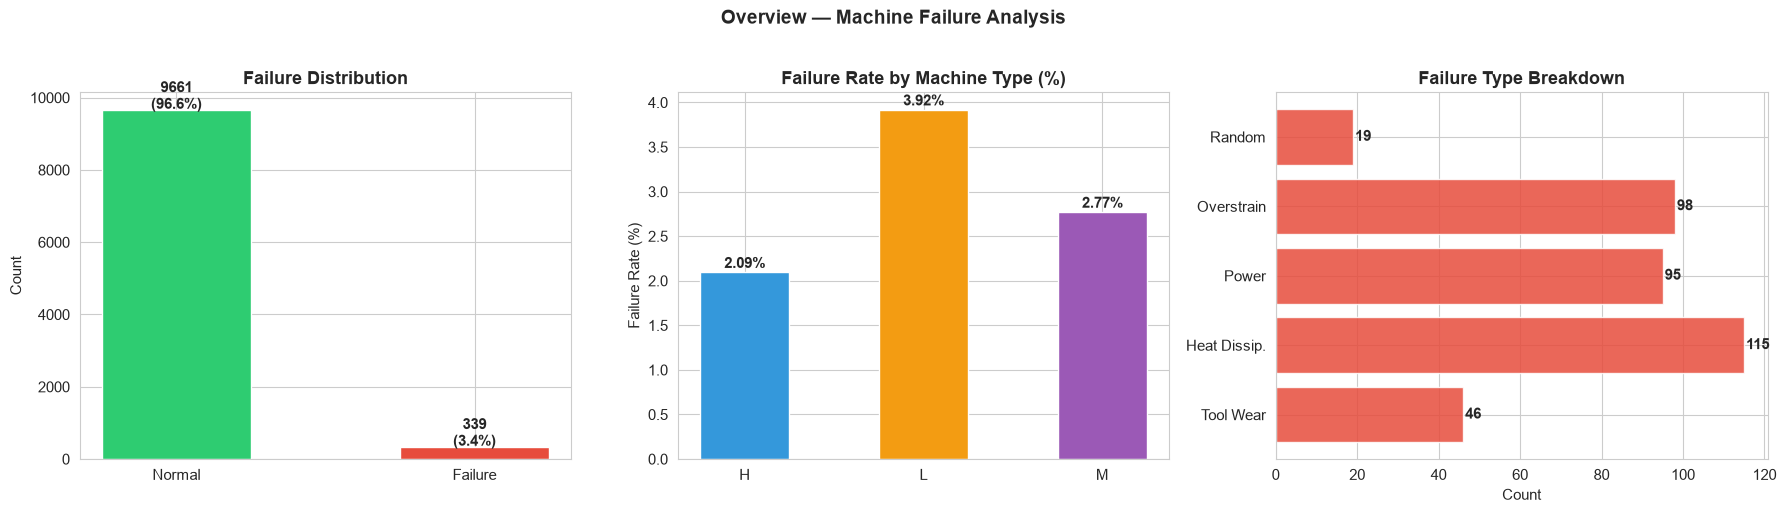

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

counts = df['Machine_failure'].value_counts()
axes[0].bar(['Normal', 'Failure'], counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_title('Failure Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

type_failure = df.groupby('Type')['Machine_failure'].mean() * 100
axes[1].bar(type_failure.index, type_failure.values,
            color=['#3498db', '#f39c12', '#9b59b6'], edgecolor='white', width=0.5)
axes[1].set_title('Failure Rate by Machine Type (%)', fontweight='bold')
axes[1].set_ylabel('Failure Rate (%)')
for i, v in enumerate(type_failure.values):
    axes[1].text(i, v + 0.05, f'{v:.2f}%', ha='center', fontweight='bold')

ft_labels = ['Tool Wear', 'Heat Dissip.', 'Power', 'Overstrain', 'Random']
ft_counts = df[['TWF', 'HDF', 'PWF', 'OSF', 'RNF']].sum()
axes[2].barh(ft_labels, ft_counts.values, color='#e74c3c', alpha=0.85, edgecolor='white')
axes[2].set_title('Failure Type Breakdown', fontweight='bold')
axes[2].set_xlabel('Count')
for i, v in enumerate(ft_counts.values):
    axes[2].text(v + 0.5, i, str(v), va='center', fontweight='bold')

plt.suptitle('Overview — Machine Failure Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/failure_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

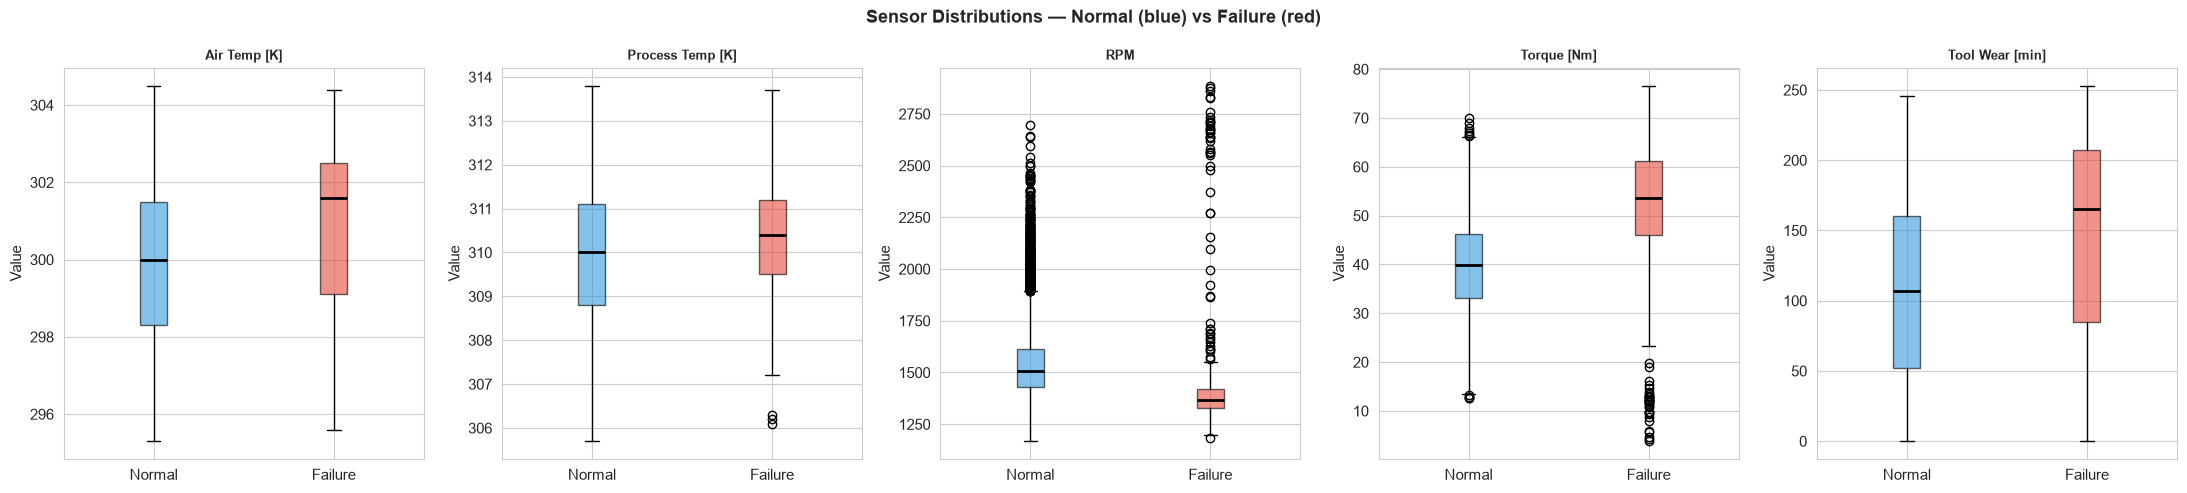

In [29]:
sensors = ['Air_temperature_K', 'Process_temperature_K',
           'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min']
labels  = ['Air Temp [K]', 'Process Temp [K]', 'RPM', 'Torque [Nm]', 'Tool Wear [min]']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for i, (col, label) in enumerate(zip(sensors, labels)):
    data_normal  = df[df['Machine_failure'] == 0][col]
    data_failure = df[df['Machine_failure'] == 1][col]
    bp = axes[i].boxplot([data_normal, data_failure],
                         tick_labels=['Normal', 'Failure'],
                         patch_artist=True,
                         medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#3498db'); bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor('#e74c3c'); bp['boxes'][1].set_alpha(0.6)
    axes[i].set_title(label, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Sensor Distributions — Normal (blue) vs Failure (red)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/sensor_trends.png', dpi=150, bbox_inches='tight')
plt.show()

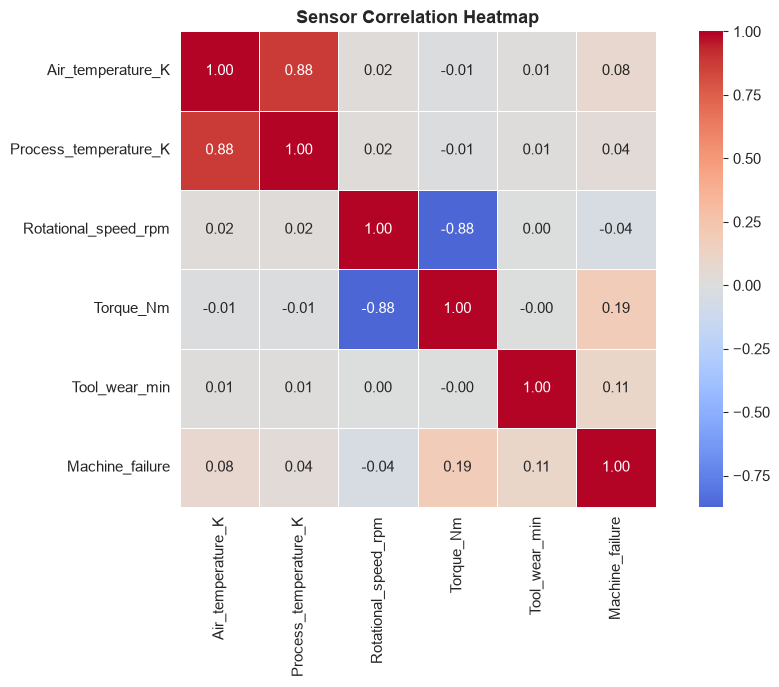

In [30]:
numeric_cols = ['Air_temperature_K', 'Process_temperature_K',
                'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Machine_failure']

plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Sensor Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 3 — Feature Engineering

In [31]:
df_feat = df.copy()

le = LabelEncoder()
df_feat['Type_encoded']      = le.fit_transform(df_feat['Type'])
df_feat['temp_delta']        = df_feat['Process_temperature_K'] - df_feat['Air_temperature_K']
df_feat['power']             = df_feat['Torque_Nm'] * (2 * np.pi * df_feat['Rotational_speed_rpm'] / 60)
df_feat['wear_rate']         = df_feat['Tool_wear_min'] / (df_feat['Rotational_speed_rpm'] + 1)
df_feat['RUL']               = df_feat['Tool_wear_min'].max() - df_feat['Tool_wear_min']
df_feat['torque_wear']       = df_feat['Torque_Nm'] * df_feat['Tool_wear_min']
df_feat['rpm_torque']        = df_feat['Rotational_speed_rpm'] * df_feat['Torque_Nm']
df_feat['temp_ratio']        = df_feat['Process_temperature_K'] / df_feat['Air_temperature_K']
df_feat['rolling_temp_5']    = df_feat['Air_temperature_K'].rolling(5, min_periods=1).mean()
df_feat['rolling_torque_10'] = df_feat['Torque_Nm'].rolling(10, min_periods=1).mean()
df_feat['lag_torque_1']      = df_feat['Torque_Nm'].shift(1)
df_feat['lag_rpm_1']         = df_feat['Rotational_speed_rpm'].shift(1)

df_feat.dropna(inplace=True)
df_feat.reset_index(drop=True, inplace=True)

print(f'Features created. Final shape: {df_feat.shape}')

Features created. Final shape: (9999, 26)


## Section 4 — ML Model Training

In [32]:
FEATURES = [
    'Air_temperature_K', 'Process_temperature_K', 'Rotational_speed_rpm',
    'Torque_Nm', 'Tool_wear_min', 'Type_encoded', 'temp_delta', 'power',
    'wear_rate', 'RUL', 'torque_wear', 'rpm_torque', 'temp_ratio',
    'rolling_temp_5', 'rolling_torque_10', 'lag_torque_1', 'lag_rpm_1'
]
TARGET = 'Machine_failure'

X = df_feat[FEATURES]
y = df_feat[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train size     : {X_train.shape[0]}')
print(f'Test size      : {X_test.shape[0]}')
print(f'Total features : {len(FEATURES)}')
print(f'Failure rate   : {y.mean():.3f}')

Train size     : 7999
Test size      : 2000
Total features : 17
Failure rate   : 0.034


In [33]:
# Random Forest — constrained depth to prevent overfitting
rf_params = {
    'n_estimators'    : [200, 300],
    'max_depth'       : [8, 12, 16],
    'min_samples_leaf': [5, 10],
    'max_features'    : ['sqrt', 0.5]
}
rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='f1', n_jobs=-1, verbose=0)
rf_grid.fit(X_train, y_train)

rf_best = rf_grid.best_estimator_
rf_pred = rf_best.predict(X_test)
rf_f1   = f1_score(y_test, rf_pred)

train_f1_rf = f1_score(y_train, rf_best.predict(X_train))
print(f'Random Forest — Best params : {rf_grid.best_params_}')
print(f'Random Forest — Train F1    : {train_f1_rf:.4f}')
print(f'Random Forest — Test  F1    : {rf_f1:.4f}')
print(f'Random Forest — Gap         : {train_f1_rf - rf_f1:.4f}')

Random Forest — Best params : {'max_depth': 16, 'max_features': 0.5, 'min_samples_leaf': 5, 'n_estimators': 200}
Random Forest — Train F1    : 0.8700
Random Forest — Test  F1    : 0.7516
Random Forest — Gap         : 0.1184


In [34]:
# XGBoost — columns already clean, no renaming needed
scale_pos = int((y_train == 0).sum() / (y_train == 1).sum())

xgb_params = {
    'n_estimators' : [200, 300],
    'max_depth'    : [4, 6],
    'learning_rate': [0.05, 0.1],
    'reg_alpha'    : [0.1, 0.5],
    'reg_lambda'   : [1.0, 2.0]
}
xgb = XGBClassifier(scale_pos_weight=scale_pos, random_state=42,
                    eval_metric='logloss', verbosity=0,
                    subsample=0.8, colsample_bytree=0.8)
xgb_grid = GridSearchCV(xgb, xgb_params, cv=5, scoring='f1', n_jobs=-1, verbose=0)
xgb_grid.fit(X_train, y_train)

xgb_best     = xgb_grid.best_estimator_
xgb_pred     = xgb_best.predict(X_test)
xgb_f1       = f1_score(y_test, xgb_pred)
train_f1_xgb = f1_score(y_train, xgb_best.predict(X_train))

print(f'XGBoost — Best params : {xgb_grid.best_params_}')
print(f'XGBoost — Train F1    : {train_f1_xgb:.4f}')
print(f'XGBoost — Test  F1    : {xgb_f1:.4f}')
print(f'XGBoost — Gap         : {train_f1_xgb - xgb_f1:.4f}')

XGBoost — Best params : {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'reg_alpha': 0.1, 'reg_lambda': 1.0}
XGBoost — Train F1    : 0.9963
XGBoost — Test  F1    : 0.8358
XGBoost — Gap         : 0.1605


In [35]:
if rf_f1 >= xgb_f1:
    best_model = rf_best
    best_pred  = rf_pred
    model_name = 'Random Forest'
else:
    best_model = xgb_best
    best_pred  = xgb_pred
    model_name = 'XGBoost'

joblib.dump(best_model, 'model/maintenance_model.pkl')
print(f'Best model : {model_name} (F1 = {max(rf_f1, xgb_f1):.4f})')
print('Model saved to model/maintenance_model.pkl')

Best model : XGBoost (F1 = 0.8358)
Model saved to model/maintenance_model.pkl


## Section 5 — Model Evaluation

In [36]:
print(f'=== {model_name} — Default Threshold (0.5) ===')
print(f'Accuracy  : {accuracy_score(y_test, best_pred):.4f}')
print(f'Precision : {precision_score(y_test, best_pred):.4f}')
print(f'Recall    : {recall_score(y_test, best_pred):.4f}')
print(f'F1 Score  : {f1_score(y_test, best_pred):.4f}')

probs = best_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, probs)

best_thresh = 0.5
best_f1     = 0.0
for thresh, p, r in zip(thresholds, precisions[:-1], recalls[:-1]):
    if r >= 0.85 and p >= 0.60:
        f = 2 * p * r / (p + r + 1e-9)
        if f > best_f1:
            best_f1     = f
            best_thresh = thresh

opt_pred = (probs >= best_thresh).astype(int)

print(f'\n=== Optimized Threshold ({best_thresh:.2f}) — Recall >= 85%, Precision >= 60% ===')
print(f'Accuracy  : {accuracy_score(y_test, opt_pred):.4f}')
print(f'Precision : {precision_score(y_test, opt_pred):.4f}')
print(f'Recall    : {recall_score(y_test, opt_pred):.4f}')
print(f'F1 Score  : {f1_score(y_test, opt_pred):.4f}')
print(f'\n{classification_report(y_test, opt_pred, target_names=["Normal", "Failure"])}')

=== XGBoost — Default Threshold (0.5) ===
Accuracy  : 0.9890
Precision : 0.8485
Recall    : 0.8235
F1 Score  : 0.8358

=== Optimized Threshold (0.35) — Recall >= 85%, Precision >= 60% ===
Accuracy  : 0.9890
Precision : 0.8286
Recall    : 0.8529
F1 Score  : 0.8406

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99      1932
     Failure       0.83      0.85      0.84        68

    accuracy                           0.99      2000
   macro avg       0.91      0.92      0.92      2000
weighted avg       0.99      0.99      0.99      2000



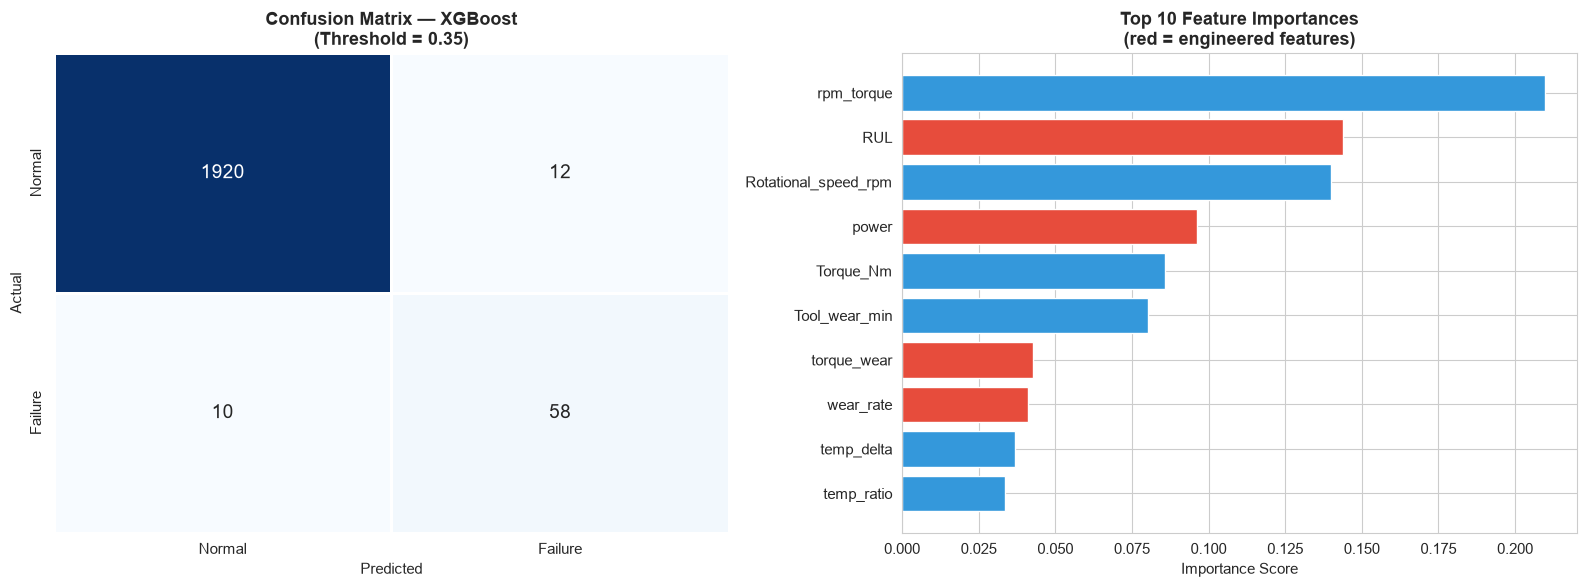

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion matrix with optimized threshold
cm = confusion_matrix(y_test, opt_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Failure'],
            yticklabels=['Normal', 'Failure'],
            linewidths=1, cbar=False, annot_kws={'size': 14})
axes[0].set_title(f'Confusion Matrix — {model_name}\n(Threshold = {best_thresh:.2f})', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Feature importance — top 10
importances = best_model.feature_importances_
feat_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True).tail(10)

colors_imp = ['#e74c3c' if f in ['torque_wear', 'power', 'RUL', 'wear_rate'] else '#3498db'
              for f in feat_df['Feature']]
axes[1].barh(feat_df['Feature'], feat_df['Importance'], color=colors_imp, edgecolor='white')
axes[1].set_title('Top 10 Feature Importances\n(red = engineered features)', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.savefig('outputs/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6 — Real-time Monitoring Simulation

In [38]:
model = joblib.load('model/maintenance_model.pkl')

HIGH_THRESHOLD   = 0.7
MEDIUM_THRESHOLD = 0.4

sample = X_test.iloc[:20].copy()
alerts = []

print('=== Real-time Monitoring Simulation ===')
print(f'{"Reading":>8} | {"Failure Prob":>12} | {"Alert Level":>14} | Action')
print('-' * 65)

for idx, (i, row) in enumerate(sample.iterrows()):
    prob = model.predict_proba(row.values.reshape(1, -1))[0][1]

    if prob >= HIGH_THRESHOLD:
        level  = 'HIGH'
        action = 'Immediate maintenance required'
    elif prob >= MEDIUM_THRESHOLD:
        level  = 'MEDIUM'
        action = 'Schedule within 7 days'
    else:
        level  = 'LOW'
        action = 'Continue monitoring'

    alerts.append({'reading': idx + 1, 'prob': prob, 'level': level, 'action': action})
    print(f'{idx+1:>8} | {prob:>12.4f} | {level:>14} | {action}')

alerts_df = pd.DataFrame(alerts)
print(f'\nHIGH alerts   : {(alerts_df["level"] == "HIGH").sum()}')
print(f'MEDIUM alerts : {(alerts_df["level"] == "MEDIUM").sum()}')
print(f'LOW alerts    : {(alerts_df["level"] == "LOW").sum()}')

=== Real-time Monitoring Simulation ===
 Reading | Failure Prob |    Alert Level | Action
-----------------------------------------------------------------
       1 |       0.0005 |            LOW | Continue monitoring
       2 |       0.0182 |            LOW | Continue monitoring
       3 |       0.0052 |            LOW | Continue monitoring
       4 |       0.0004 |            LOW | Continue monitoring
       5 |       0.0006 |            LOW | Continue monitoring
       6 |       0.0262 |            LOW | Continue monitoring
       7 |       0.0031 |            LOW | Continue monitoring
       8 |       0.0005 |            LOW | Continue monitoring
       9 |       0.0018 |            LOW | Continue monitoring
      10 |       0.0003 |            LOW | Continue monitoring
      11 |       0.0002 |            LOW | Continue monitoring
      12 |       0.0096 |            LOW | Continue monitoring
      13 |       0.0003 |            LOW | Continue monitoring
      14 |       0.0052 |

## Section 7 — Maintenance Scheduling

In [39]:
model     = joblib.load('model/maintenance_model.pkl')
all_probs = model.predict_proba(X_test)[:, 1]

schedule_df = df_feat.loc[X_test.index, ['Product_ID', 'Type', 'Tool_wear_min', 'Torque_Nm']].copy()
schedule_df['failure_probability'] = all_probs

def assign_priority(prob):
    if prob >= HIGH_THRESHOLD:   return 'HIGH'
    elif prob >= MEDIUM_THRESHOLD: return 'MEDIUM'
    return 'LOW'

def assign_days(prob):
    if prob >= HIGH_THRESHOLD:   return 1
    elif prob >= MEDIUM_THRESHOLD: return 7
    return 30

schedule_df['priority']            = schedule_df['failure_probability'].apply(assign_priority)
schedule_df['maintenance_in_days'] = schedule_df['failure_probability'].apply(assign_days)

high_risk = schedule_df[schedule_df['priority'] != 'LOW'].sort_values(
    'failure_probability', ascending=False).head(15)

print('=== Maintenance Schedule — Top At-Risk Machines ===')
print(high_risk[['Product_ID', 'Type', 'Tool_wear_min', 'failure_probability',
                  'priority', 'maintenance_in_days']].to_string(index=False))

=== Maintenance Schedule — Top At-Risk Machines ===
Product_ID Type  Tool_wear_min  failure_probability priority  maintenance_in_days
    M19202    M            111             0.999437     HIGH                    1
    L56844    L            231             0.999160     HIGH                    1
    M23105    M            111             0.999138     HIGH                    1
    L47428    L            216             0.999090     HIGH                    1
    L49624    L             76             0.999062     HIGH                    1
    L51841    L             32             0.999018     HIGH                    1
    L56196    L            212             0.998882     HIGH                    1
    L49885    L             71             0.998852     HIGH                    1
    H33979    H             25             0.998398     HIGH                    1
    L51310    L             22             0.998371     HIGH                    1
    L51675    L             67             0.9

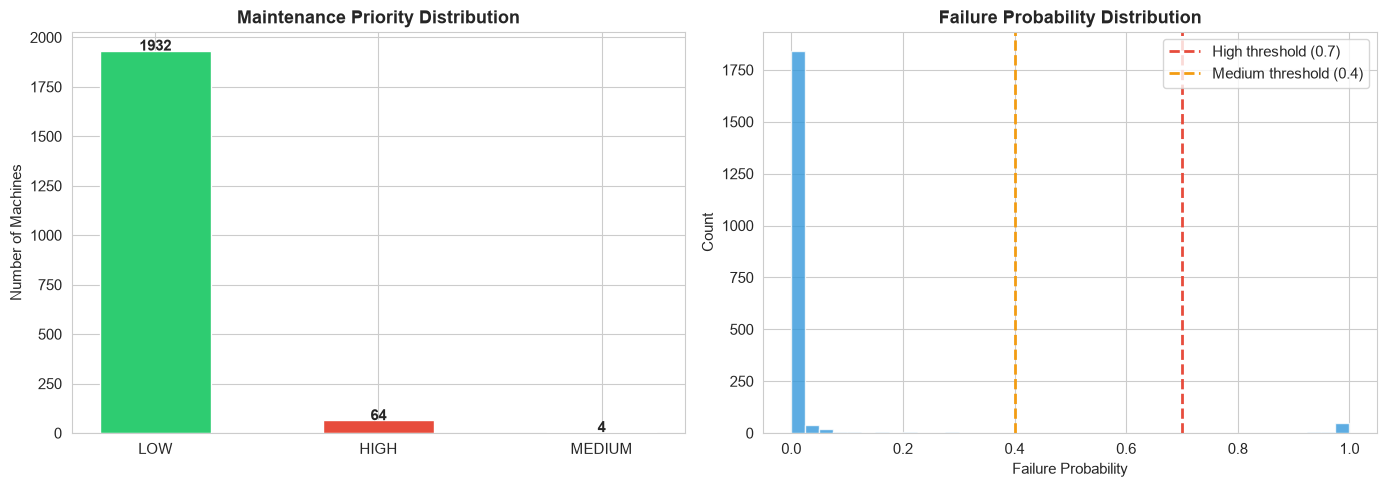


All outputs saved to outputs/ folder
Model saved to model/maintenance_model.pkl


In [40]:
priority_counts = schedule_df['priority'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'HIGH': '#e74c3c', 'MEDIUM': '#f39c12', 'LOW': '#2ecc71'}
bar_colors = [colors[p] for p in priority_counts.index]

axes[0].bar(priority_counts.index, priority_counts.values, color=bar_colors, edgecolor='white', width=0.5)
axes[0].set_title('Maintenance Priority Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Machines')
for i, v in enumerate(priority_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

axes[1].hist(all_probs, bins=40, color='#3498db', edgecolor='white', alpha=0.8)
axes[1].axvline(HIGH_THRESHOLD, color='#e74c3c', linestyle='--', linewidth=2, label='High threshold (0.7)')
axes[1].axvline(MEDIUM_THRESHOLD, color='#f39c12', linestyle='--', linewidth=2, label='Medium threshold (0.4)')
axes[1].set_title('Failure Probability Distribution', fontweight='bold')
axes[1].set_xlabel('Failure Probability')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/maintenance_schedule.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nAll outputs saved to outputs/ folder')
print('Model saved to model/maintenance_model.pkl')